<div style="text-align: center;">
  <h3>FRANCO DAVID BARRIONUEVO, JOHANNA MONTOYA CANO</h3>
  <h1><b>Maestría en Aplicaciones de Información Espacial (MAIE), I. Gulich</b></h1>
  <h2>Programación y Métodos Numéricos orientados al tratamiento de imágenes satelitales</h2>
  <h4>Trabajo Práctico Final</h4>
  <p>Profesores: Carolina Tauro, César Germán Maglione</p>
  <p>Junio 22, 2026</p>
</div>

---

# Simulación numérica y análisis de estabilidad de las interacciones nube-lluvia con base en el modelo de Pujol y Jensen (2019)


# 1. Introducción

Las nubes constituyen un sistema dinámico no lineal complejo con muchos grados de libertad e interacciones en un amplio rango de escalas espaciotemporales. A pesar de esta complejidad, algunos aspectos de su comportamiento a macroescala, como lo es la interacción entre gotitas de nubes (cloud droplets) y la precipitación, son predecibles sin necesidad de considerar la complejidad total de este sistema dinámico.

Un modelo que intentó explicar la interacción entre el agua de la nube, la formación de lluvia y la consecuente precipitación fue el modelo de Ecuaciones Diferenciales con Retraso (DDEs, por sus siglas en inglés) de Koren y Feingold [1], el cual modela el tiempo de maduración que requiere el agua de la nube para transformarse en lluvia mediante un desfase temporal rígido ($t - T$) y considerando interacciones del tipo Depredador - Presa.

En general, las DDEs tienen esta forma:

$$\dfrac{dx}{dt} = f(t, x(t), x(t - T))$$

Matemáticamente, estas ecuaciones con retraso transforman el sistema en un problema de dimensión infinita, ya que el estado en un tiempo $t + dt$ no depende únicamente del estado en el instante $t$ sino también de lo que pasó en el instante $t-T$. Esto genera una cadena de dependencia hacia atrás donde, para conocer el estado en $t-T$, es necesario conocer lo que sucedió en el instante $t-2T$, obligando al algoritmo a arrastrar una función histórica continua en lugar de una condición inicial puntual.

Pujol y Jensen [2] hicieron un análisis cualitativo del modelo de Koren y Feingold y demostraron que ese retraso T en las DDEs destruye la estructura geométrica del espacio de fases, impidiendo la coexistencia estable de nubes y lluvia  y provocando que decaigan hacia la extinción o hacia puntos fijos estáticos, lo cual no modela adecuadamente las oscilaciones periódicas perpetuas de carga y descarga de lluvia.

Pujol y Jensen propusieron un modelo de tres Ecuaciones Diferenciales Ordinarias (EDOs) que mantiene la simplicidad de las interacciones definidas por el modelo de Koren y Feingold pero que al incorporar EDOs en lugar DDEs soluciona el problema de retraso. La forma general de una EDO está dada por:

$$\dfrac{dx}{dt} = f(t, x(t))$$

# 2. El modelo de Pujol y Jensen

El modelo de Pujol y Jensen incorpora competencia de poblaciones, interacciones y capacidad de carga de una forma natural. Acá las poblaciones corresponden al contenido de agua en forma de nube $L_c(t)$ ($\text{g/cm}^3$), el contenido de agua en forma de lluvia $L_r(t)$ ($\text{g/cm}^3$), y la concentación numérica de gotitas en la nube (cloud droplets) $N_d(t)$ ($1/cm³$).

El modelo consta de tres EDOs acopladas, una para $L_c(t)$, otra para $L_r(t)$, y una para $N_d(t)$. El sistema incluye tres procesos principales que contribuyen a los balances de nube en $L_c$, $L_r$ y $N_d$: (1) fuentes/sumideros que representan intercambios con el entorno, y dos procesos internos, (2) la autoconversión de agua de nube en agua de lluvia, y (3) la acreción de agua de nube por parte del agua de lluvia.



## 2.1 EDOs del sistema de ecuaciones de Pujol y Jensen

El sistema de ecuaciones de Pujol y Jensen está dado por las siguientes tres EDOs:

\begin{align}
\frac{dL_c}{dt} &= A_cL_c - B_c(N_d)L_c^4 - k_rL_cL_r \\
\frac{dL_r}{dt} &= -A_rL_r + B_c(N_d)L_c^4 + k_rL_cL_r \\
\frac{dN_d}{dt} &= A_c(N_0-N_d)-\frac{4}{3}k_cL_c^2-k_rL_rN_d
\end{align}

Donde:

* **$L_c(t)$ (concentración de agua en forma de nube en la atmósfera medida en $\text{g/cm}^3$):** Representa la masa total de gotitas microscópicas (cloud droplets) suspendidas por unidad de volumen. Es la "Presa".

* **$L_r(t)$ (concentración de agua en forma de lluvia en la atmósfera medida en $\text{g/cm}^3$):** Representa la masa total de gotas grandes y pesadas (raindrops) por unidad de volumen. Es el "Depredador".

* **$N_d(t)$ (Concentración numérica de gotitas de agua en forma de nube ($1/cm³$):** Es la cantidad (número) de gotitas microscópicas individuales que forman la nube. No mide su masa, sino cuántas hay. $N_d$ influye en la velocidad a la que una gotita microscópica de nube alcanza el tamaño crítico para precipitar (entre menos gotitas, mayor es la tasa de precipitación).

## 2.2. Parámetros del modelo

El comportamiento del sistema está regulado por un conjunto de parámetros constantes que definen las escalas temporales y las propiedades microfísicas de la atmósfera:

* **$A_c$ Tasa constante de crecimiento proporcional de la nube:** Representa la velocidad de formación y crecimiento de la nube (nucleación), la cual depende de la evaporación y las corrientes de aire ascendentes.

* **$A_r$ Tasa constante de decaimiento (o pérdida) proporcional de la lluvia:**  Representa la tasa de precipitación (*rain out*); mide qué tan rápido la gravedad saca el agua lluvia del sistema aéreo hacia el suelo.

* **$N_0$ Concentración de aerosoles de fondo:** Condición ambiental o meteorológica externa que representa el límite de núcleos de condensación en el aire circundante. Es un parámetro fijo que define qué tan limpia, marítima o contaminada está esa porción de atmósfera de manera constante.

* **$Bc(Nd)$ Coeficiente de autoconversión:** Es la tasa que define qué tan rápido las gotitas de la nube chocan entre sí de forma espontánea para volverse gotas de lluvia.

  $B_c(N_d) = \frac{K}{N_d^2}$
  
  Como se ve, $Bc$ es inversamente proporcional a $N_d^2$, lo que significa que cuanto mayor es el número de gotitas ($N_d$ alto), más chico se vuelve $B_c$ y más se frena la lluvia.
  
  K es la constante física de autoconversión, es un factor fijo estimado con base en la física atmosférica, la cual agrupa constantes de gravedad, la densidad del agua líquida, la viscosidad del aire y propiedades geométricas de las gotas.

* **$k_r$ Constante microfísica de colisión - barrido de acreción:** Coeficiente que mide la probabilidad matemática de que una gota de lluvia que cae a través de la nube absorba a las gotitas microscópicas que encuentra en su camino.

* **$k_c$ Constante microfísica de colisión - coalescencia mutua:** Coeficiente que mide la probabilidad matemática de que dos gotitas de nube de tamaños microscópicos y relativamente similares choquen y se fusionan para formar una sola gota más grande.

## 2.3. Fundamentos y dinámica del modelo

El modelo de Pujol y Jensen es un modelo macroscópico (*bulk model*) lo que significa que $L_c$, $L_r$ y $N_d$ representan promedios globales de toda la nube, simplificando la microfísica en tres ecuaciones acopladas.

De acuerdo con el análisis de los autores, la dinámica del sistema se puede entender a través de tres grandes interacciones:

* **El bucle Predador-Presa y sus escalas temporales:** Si se observa la interacción básica, la nube ($L_c$) actúa como la presa y la lluvia ($L_r$) como el depredador. El crecimiento de la nube está impulsado por factores ambientales ($A_c$), mientras que la lluvia decae naturalmente por la gravedad ($A_r$). Cuando interactúan, las gotas de lluvia al caer "barren" y absorben la masa de la nube mediante un proceso de **acreción** gobernado por la constante $k_r$, que equivale a la tasa de caza en el modelo de Lotka-Volterra.

* **La autoconversión cuártica como capacidad de carga:** En un sistema biológico clásico, las presas crecerían hasta el infinito si no hubiera depredadores. En la atmósfera no ocurre esto y para restringrlo los autores introducen en el un término de **autoconversión** ($-B_c L_c^4$), que representa cómo las gotitas de la nube chocan espontáneamente entre sí hasta volverse lo suficientemente pesadas como para convertirse en lluvia. Matemáticamente, este término de orden cuatro actúa como una **capacidad de carga (carrying capacity)** que frena el crecimiento desmedido de la nube por sí sola.

* **El puente dinámico de las gotitas ($N_d$) y los ciclos límite:** Lo que vuelve realista a este modelo es que la capacidad de carga no sea un valor fijo. El coeficiente de autoconversión ($B_c = K/N_d^2$) es variable y está dado por la tercera ecuación, la de la concentración numérica de gotitas ($N_d$). La población de gotitas se alimenta de los aerosoles de fondo ($N_0$), pero disminuye por su propia fusión interna (**coalescencia mutua**, $k_c$) y por el barrido de la lluvia (**acreción**, $k_r$). Al bajar $N_d$, el freno de la autoconversión se debilita y se dispara la lluvia.

Como las masas de agua físicas están naturalmente acotadas en la atmósfera, de acuerdo con Pujol y Jensen, el **Teorema de Poincaré-Bendixson** garantiza que este modelo que se retroalimenta no se desborde, sino que converja de forma natural hacia un **ciclo límite** que se manifiesta como oscilaciones perpetuas de carga y descarga de la lluvia.

# 3. Metodología

Debido a la no linealidad y al acoplamiento dinámico del sistema de ecuaciones de Pujol y Jensen, no es posible obtener una solución analítica exacta. Por lo tanto, para estudiar el comportamiento del sistema y sustentar los comportamiento predichos en el paper, se recurre a la simulación numérica. Para tla fin, se ha implementado el método de integración de Euler que permite aproximar las trayectorias temporales de la concentración de agua nube ($L_c$), la concentración de agua lluvia ($L_r$) y la concentración de gotitas ($N_d$)



### 3.1. El método de Euler

**Descripción del método**

El método de Euler es un procedimiento numérico sistemático de primer orden que permite aproximar la solución de una Ecuación Diferencial Ordinaria (EDO) de la forma $\dot{x} = f(t, x)$ a partir de una condición inicial dada $x(t_0) = x_0$.

El algoritmo consiste en aproximar los estados futuros de la variable $x(t)$ de forma iterativa a partir de la siguiente relación de recurrencia:

$$x_{n+1} = x_{n} + f(t_n, x_{n})\Delta t$$

Es decir, la solución aproximada se construye como una sucesión de puntos discretos donde cada nuevo valor ($x_{n+1}$) se obtiene sumando al estado anterior ($x_n$) un incremento determinado por el producto entre el paso temporal ($\Delta t$) y la pendiente local de la función evaluada en el instante actual ($f(t_n, x_n)$).

Cuanto más pequeño es el intervalo de tiempo ($\Delta t$) mejor es la aproximación pero el tiempo de cómputo puede ser muy grande.

**Precisión y Limitaciones del Método**

La aproximación a la solución real de la EDO depende críticamente del tamaño del paso temporal ($\Delta t$):
* **Error de Truncamiento Local:** En cada paso individual, el método comete un error de orden $\mathcal{O}(\Delta t^2)$ debido a que aproxima la curva real mediante una línea recta (la tangente).
* **Error de Truncamiento Global:** Al acumular los errores de todos los pasos a lo largo del tiempo, el error total es de orden $\mathcal{O}(\Delta t)$. Esto significa que si se reduce el paso del tiempo a la mitad, el error global también se reducirá aproximadamente a la mitad.

Por lo tanto, para sistemas no lineales y acoplados (como el modelo de nubes y lluvia), el valor de $\Delta t$ debe ser lo suficientemente pequeño para evitar que las aproximaciones numéricas diverjan de la física real del problema.


### 3.2 Definición de la función de Euler en Python para un sistema de tres EDOs

A continuación se define la función *euler_solver_3d*  para obtener la solución numérica por el método de Euler para un sistema de 3 EDOS en Python.

In [ ]:
#Importamos librerías
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Definimos la función de Euler para un sistema de tres EDOs
def euler_solver_3d(f1, f2, f3, t0, tf, x10, x20, x30, h):
    '''
    f1: EDO f(x1, x2, x3); f2: EDO g(x1, x2, x3); f3: EDO h(x1, x2, x3)
    t0: Tiempo inicial; tf: Tiempo final
    x10, x20 y x30: Condiciones iniciales dimensiones 1, 2 y 3
    h: Timestep
    '''

    # Cantidad de pasos
    steps = int((tf-t0)/h)

    # Inicializamos variables y listas
    x1 = x10
    x2 = x20
    x3 = x30
    t = t0

    t_list = [t]
    x1_list = [x1]
    x2_list = [x2]
    x3_list = [x3]

    # Bucle de integración numérica
    for i in range(steps):

        x1_actual = x1
        x2_actual = x2
        x3_actual = x3

        x1 = x1_actual + h*f1(t, x1_actual, x2_actual, x3_actual)
        x2 = x2_actual + h*f2(t, x1_actual, x2_actual, x3_actual)
        x3 = x3_actual + h*f3(t, x1_actual, x2_actual, x3_actual)
        t = t + h

        t_list.append(t)
        x1_list.append(x1)
        x2_list.append(x2)
        x3_list.append(x3)

    return np.array(t_list), np.array(x1_list), np.array(x2_list), np.array(x3_list)

# 4. Resultados

## 4.1 Definición de las EDOs de Pujol y Jensen

A continuación se define el sistema de ecuaciones con base en los parámetros dados por Pujol y Jensen, para luego integrarlas numéricamente por el método de integración de Euler usando el script desarrollado en el punto 3.2.


In [ ]:
# Definimos cada una de las EDOs del sistema
def dLcdt(t, Lc, Lr, Nd):
    bc = K * Nd**(-2)
    return AC*Lc - bc*Lc**4 - KR*Lc*Lr

def dLrdt(t, Lc, Lr, Nd):
    bc = K * Nd**(-2)
    return -AR*Lr + bc*Lc**4 + KR*Lc*Lr

def dNddt(t, Lc, Lr, Nd):
    bc = K * Nd**(-2)
    return AC*(N0 - Nd) - (4/3)*KC*Lc**2 - KR*Lr*Nd

**Valores numéricos de los parámetros:**

Para correr la simulación se configuran las constantes del modelo con los siguientes valores extraídos de las condiciones de simulación del artículo original:

* **$A_c$** = $0.02 \text{ min}^{-1}$
* **$A_r$** = $0.1 \text{ min}^{-1}$
* **$K$** = $2.905 \times 10^{17} \text{ cm}^3 \cdot \text{g}^{-3} \cdot \text{min}^{-1}$
* **$k_r$** = $3.47 \times 10^{5} \text{ cm}^3 \cdot \text{g}^{-1} \cdot \text{min}^{-1}$
* **$k_c$** = $5.66 \times 10^{11} \text{ cm}^3 \cdot \text{g}^{-2} \cdot \text{min}^{-1}$

In [ ]:
# Definimos el paso de integración
H = 0.0005

# Definimos los valores de los parámetros
AC = 0.02 # min-1
AR = 0.1 # min-1
K = 2.905e17 # cm3 g-3 min-1
KR = 3.47e5 # cm3 g-1 min-1
KC = 5.66e11 # cm3 g-2 min-1


## 4.2. Puntos de equilibrio y análisis de estabilidad

### 4.2.1. Puntos de equilibrio

De acuerdo con el planteamiento de Pujol y Jensen, el análisis de estabilidad local se simplifica al limitar el estudio a las dos primeras ecuaciones diferenciales del sistema ($L_c$ y $L_r$), tratando a la concentración de núcleos de condensación ($N_d$) no como una variable dinámica, sino como un parámetro constante.

Así, para encontrar los puntos de equilibrio del sistema basta con encontrar los puntos que satisfacen

\begin{align}
\frac{dL_c}{dt} &= A_cL_c - B_c(N_d)L_c^4 - k_rL_cL_r = 0\\
\frac{dL_r}{dt} &= -A_rL_r + B_c(N_d)L_c^4 + k_rL_cL_r = 0\\
\end{align}

#### **Punto de equilibrio trivial**
El primer punto crítico (o equilibrio trivial) surge de manera inmediata al evaluar el origen $X_e^{(1)} = (0,0)$. Si se sustituyen las variables de estado por cero ($L_c = 0$ y $L_r = 0$), todos los términos de ambas ecuaciones se anulan, satisfaciendo de forma trivial el sistema. Físicamente, este punto representa un estado de "cielo despejado", en donde al no existir agua líquida inicial en la atmósfera, no hay masa que pueda desencadenar los procesos microfísicos de autoconversión o recolección, por lo que el sistema permanece estático.

De esta condición, se deduce directamente que la concentración de núcleos de condensación se mantiene en su valor base ($N_d = N_0$); al no haber nubes ni lluvia que interactúen con los aerosoles de la atmósfera, su cantidad no sufre ninguna alteración.

#### **Punto de equilibrio no trivial**

El segundo punto crítico $X_e^{(2)} = (L_c^{(e)}, L_r^{(e)})$ representa el estado de coexistencia entre el agua de la nube y la lluvia. Para encontrar analíticamente estos valores, el artículo plantea un balance de masa global sumando ambas ecuaciones de equilibrio. Como los procesos internos de autoconversión y recolección se cancelan mutuamente por tener signos opuestos, se obtiene una relación lineal directa entre ambos contenidos de agua dada por sus tasas externas ($A_c L_c^{(e)} = |A_r| L_r^{(e)}$).

Al sustituir la equivalencia de $L_c^{(e)}$ en la ecuación original de la nube, las expresiones se reducen a un polinomio de tercer grado definido por la función del agua de lluvia ($L_r^{(e)}$):

$$B_c(N_d)\dfrac{|A_r|^3}{A_c ^4}\left(L_r^{(e)}\right)^3 + \dfrac{k_r}{A_c}L_r^{(e)} - 1 = 0$$

Dado que los dos primeros términos de este polinomio son estrictamente positivos, se garantiza que de sus tres soluciones, dos sean complejas conjugadas (sin sentido físico) y exista una única raíz real positiva. Esta solución única define el segundo y último punto de equilibrio del sistema.

Dado que $B_c(N_d)$ varía según el escenario definido, el valor del punto crítico no trivial también será diferente.

#### 4.2.2. Función para el análisis de estabilidad de puntos críticos

Para analizar la estabilidad de los puntos críticos se implementó un script que automatiza el cálculo de la matriz Jacobiana y la extracción de sus autovalores, y su clasificacion, posterio a la resolución del polinomio característico para cada punto crítico.


In [ ]:
# DEFINICIÓN DE FUNCIÓN PARA EL ANÁLISIS DE ESTABILIDAD DE PUNTOS CRÍTICOS
import cmath

# Define una función para el cómputo de la matriz jacobiana
def cps(df_dx, df_dy, dg_dx, dg_dy, x_cp, y_cp):

    a = df_dx(x_cp, y_cp)
    b = df_dy(x_cp, y_cp)
    c = dg_dx(x_cp, y_cp)
    d = dg_dy(x_cp, y_cp)

    return a, b, c, d

# Define Bhaskara solver para obtener autovalores
def get_eigenval(df_dx, df_dy, dg_dx, dg_dy, x_cp, y_cp):

    a, b, c, d = cps(df_dx, df_dy, dg_dx, dg_dy, x_cp, y_cp)
    #print(a, b, c, d)

    bhask_a = 1
    bhask_b = (-1)*(a + d)
    bhask_c = (a*d-b*c)

    eigV1 = ((-bhask_b) + cmath.sqrt(bhask_b**2-4*bhask_a*bhask_c))/(2*bhask_a)
    eigV2 = ((-bhask_b) - cmath.sqrt(bhask_b**2-4*bhask_a*bhask_c))/(2*bhask_a)

    return eigV1, eigV2

# Define una función para clasificación de los puntos críticos
def cp_stab(df_dx, df_dy, dg_dx, dg_dy, x_cp, y_cp):

    # Gen eigenvalues result
    eigV1, eigV2 = get_eigenval(df_dx, df_dy, dg_dx, dg_dy, x_cp, y_cp)

    # Print critical point
    print(f'X*: {x_cp}; Y*: {y_cp}')

    # Print eigenvalues
    print(f'Lambda1: {eigV1}; Lambda2: {eigV2}')

    if abs(eigV1.imag) > 1e-12 or abs(eigV2.imag) > 1e-12:

        if abs(eigV1.real) < 1e-12 and abs(eigV2.real) < 1e-12: # No real component
            print('Centro. Estable')

        elif eigV1.real > 0:
            print('Punto espiral. Inestable')

        else:
            print('Punto espiral. Asintóticamente estable')

    else: # Eigenvalues with no imaginary component (purely real)

        eigV1 = eigV1.real
        eigV2 = eigV2.real

        if eigV1 > 0 and eigV2 > 0: # Positive values

            if eigV1 == eigV2:
                print('Nodo propio/Impropio. Inestable')

            else: # eigV1 > eigV2 or eigV1 < eigV2
                print('Nodo impropio. Inestable')

        elif eigV1 < 0 and eigV2 < 0:

            if eigV1 == eigV2:
                print('Nodo propio/Impropio. Asintóticamente estable')

            else: # eigV1 > eigV2 or eigV1 < eigV2
                print('Nodo impropio. Asintóticamente estable')

        elif eigV1 * eigV2 < 0:
            print('Punto silla. Inestable')

In [ ]:
# Se definen las derivadas parciales del modelo de Pujol y Jensen para Lc y Lr

## Derivadas parciales de Lc
def df_dx(x, y):
    return AC - 4*bc*x**3 - KR*y

def df_dy(x, y):
    return -KR*x

## Derivadas parciales de Lr
def dg_dx(x, y):
    return 4*bc*x**3 + KR*y

def dg_dy(x, y):
    return -AR + KR*x

### 4.2.2. Estabilidad de los puntos de equilibrio

#### 4.2.2.1. Análisis de estabilidad del punto de equilibrio trivial $X_e^{(1)} = (0,0)$

El resultado numérico obtenido mediante el algoritmo (Nodo inestable del tipo Punto silla) valida de forma exacta las deducciones analíticas presentadas en el artículo. Al evaluar el origen, los autovalores reales presentan signos opuestos ($\lambda_1 > 0$ y $\lambda_2 < 0$), lo que define la existencia de un punto de silla.

Físicamente, esto significa que el estado de "cielo despejado" (sin nube ni lluvia) es inestable: cualquier pequeña perturbación o humedad en el ambiente romperá el equilibrio, haciendo que la nube empiece a crecer y alejando al sistema del origen.

In [ ]:
N0 = 50 # Se define N0 = 50 según casos evaluados posteriormente
bc = K * N0**(-2) # Se recomputa bc para cada caso

# Análsis de estabilidad par el punto crítico (0,0)
cp_stab(df_dx, df_dy, dg_dx, dg_dy, 0, 0)

X*: 0; Y*: 0
Lambda1: (0.019999999999999997+0j); Lambda2: (-0.1+0j)
Punto silla. Inestable


#### 4.2.2.2. Equilibrios no triviales: análisis de escenarios


Debido a la complejidad que representa la resolución de los valores para los puntos de equilibrio no triviales, se optó por el uso de una herramienta de la librería Scipy de Python para su cómputo. Para ello se empleó la función *fsolve* que permite calcular los raices del sistema de ecuaciones multivarible empleando el método *hybr*

In [ ]:
# Se importa la función fsolve
from scipy.optimize import fsolve

# Se define el sistema de ecuaciones sobre el cual se desea hallar los puntos
# de equilibrio no triviales (Sist. de Pujol & Jensen)
def equilibrium_system(X): # SISTEMA EN EQUILIBRIO (dLc/dt=0, dLr/dt=0, dNd/dt=0)
    Lc, Lr, Nd = X
    bc_local = K * Nd**(-2)
    return [
        AC*Lc - bc_local*Lc**4 - KR*Lc*Lr,
        -AR*Lr + bc_local*Lc**4 + KR*Lc*Lr,
        AC*(N0 - Nd) - (4/3)*KC*Lc**2 - KR*Lr*Nd
        ]

**Análisis escenarios con variaciones de la condición inicial $N_d(0)$ y del parámetro $N_0$ (aerosoles de fondo)**

Con el objetivo de comprender cómo la disponibilidad de núcleos de condensación de fondo ($N_0$) afecta el modelo de Pujol y Jensen, se plantearon tres escenarios a partir de la relación entre la concentración inicial de gotitas ($N_d(0)$) y el techo ambiental de aerosoles ($N_0$).

* **Escenario 1 — Excedente ambiental de aerosoles ($N_d(0) < N_0$):** Configurado con $N_0 = 50 \text{ cm}^{-3}$ y $N_d(0) = 10 \text{ cm}^{-3}$, este escenario simula una masa de aire limpia (típica de entornos marítimos puros) donde la nube inicia subdesarrollada respecto al potencial de su entorno.

* **Escenario 2 — Equilibrio higroscópico inicial ($N_d(0) = N_0$):** Configurado con $N_0 = 50 \text{ cm}^{-3}$ y $N_d(0) = 50 \text{ cm}^{-3}$, representa un estado ambientalmente neutro donde la totalidad de los aerosoles disponibles de fondo ya han sido activados y transformados en gotitas al inicio de la simulación. Esto permite aislar el transitorio inicial y evaluar la respuesta de la nube guiada puramente por las tasas de autoconversión y acreción interna.

* **Escenario 3 — Déficit ambiental de aerosoles ($N_d(0) > N_0$):** Configurado con un entorno empobrecido de fondo ($N_0 = 10 \text{ cm}^{-3}$) frente a una población inicial sobredimensionada de gotitas ($N_d(0) = 100 \text{ cm}^{-3}$). Si bien no es el escenario más probable, podría ocurrir por el desplazamiento de una nube con gotas activadas a una de menor concentraciónd de aerosoles.



In [ ]:
# ESTABILIDAD - ESCENARIO 1

# --- ESCENARIO 1: Nd(0) < N0 ---
print("=== ESCENARIO 1 ===")
# Parámetros y condiciones iniciales
N0 = 50
ND0 = 10
LC0 = 10e-9
LR0 = 0
# Cálculo del punto crítico usando fsolve
eq_1 = fsolve(equilibrium_system, [1e-6, 1e-6, N0])
print("Punto crítico no trivial encontrado:")
print(f"  Lc eq: {eq_1[0]:.4e} g/cm3")
print(f"  Lr eq: {eq_1[1]:.4e} g/cm3")
print(f"  Nd eq: {eq_1[2]:.2f} cm-3")
# Análisis de estabilidad
bc = K * eq_1[2]**(-2)
print("Estabilidad:")
cp_stab(df_dx, df_dy, dg_dx, dg_dy, eq_1[0], eq_1[1])
print("-" * 40)


=== ESCENARIO 1 ===
Punto crítico no trivial encontrado:
  Lc eq: 4.7742e-07 g/cm3
  Lr eq: 9.7010e-08 g/cm3
  Nd eq: 15.43 cm-3
Estabilidad:
X*: 4.774192502911907e-07; Y*: 9.7009958105306e-08
Lambda1: (0.02573544931969718+0.06379917214587538j); Lambda2: (0.02573544931969718-0.06379917214587538j)
Punto espiral. Inestable
----------------------------------------


/tmp/ipykernel_10173/559043066.py:11: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  eq_1 = fsolve(equilibrium_system, [1e-6, 1e-6, N0])


In [ ]:
# ESTABILIDAD - ESCENARIO 2

# --- ESCENARIO 2: Nd(0) = N0 ---
print("=== ESCENARIO 2 ===")
# Parámetros y condiciones iniciales
N0 = 50
ND0 = 50
LC0 = 10e-9
LR0 = 0
# Cálculo del punto crítico usando el final de Euler como semilla
eq_2 = fsolve(equilibrium_system, [1e-6, 1e-6, N0])
print("Punto crítico no trivial encontrado:")
print(f"  Lc eq: {eq_2[0]:.4e} g/cm3")
print(f"  Lr eq: {eq_2[1]:.4e} g/cm3")
print(f"  Nd eq: {eq_2[2]:.2f} cm-3")
# Análisis de estabilidad
bc = K * eq_2[2]**(-2)
print("Estabilidad:")
cp_stab(df_dx, df_dy, dg_dx, dg_dy, eq_2[0], eq_2[1])
print("-" * 40)

=== ESCENARIO 2 ===
Punto crítico no trivial encontrado:
  Lc eq: 4.7742e-07 g/cm3
  Lr eq: 9.7010e-08 g/cm3
  Nd eq: 15.43 cm-3
Estabilidad:
X*: 4.774192502911907e-07; Y*: 9.7009958105306e-08
Lambda1: (0.02573544931969718+0.06379917214587538j); Lambda2: (0.02573544931969718-0.06379917214587538j)
Punto espiral. Inestable
----------------------------------------


/tmp/ipykernel_10173/1465525787.py:11: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  eq_2 = fsolve(equilibrium_system, [1e-6, 1e-6, N0])


In [ ]:
# ESTABILIDAD - ESCENARIO 3

# --- ESCENARIO 3: Nd(0) > N0 ---
print("=== ESCENARIO 3 ===")
# Parámetros y condiciones iniciales
N0 = 10
ND0 = 100
LC0 = 10e-9
LR0 = 0
# Cálculo del punto crítico
eq_3 = fsolve(equilibrium_system, [1e-6,1e-6,N0])
print("Punto crítico no trivial encontrado:")
print(f"  Lc eq: {eq_3[0]:.4e} g/cm3")
print(f"  Lr eq: {eq_3[1]:.4e} g/cm3")
print(f"  Nd eq: {eq_3[2]:.2f} cm-3")
# Análisis de estabilidad
bc = K * eq_3[2]**(-2)
print("Estabilidad:")
cp_stab(df_dx, df_dy, dg_dx, dg_dy, eq_3[0], eq_3[1])
print("-" * 40)

=== ESCENARIO 3 ===
Punto crítico no trivial encontrado:
  Lc eq: 2.9687e-07 g/cm3
  Lr eq: 5.9325e-08 g/cm3
  Nd eq: 3.29 cm-3
Estabilidad:
X*: 2.968651807038021e-07; Y*: 5.9325289086743314e-08
Lambda1: (-0.00019188300541117878+0.04898781385712969j); Lambda2: (-0.00019188300541117878-0.04898781385712969j)
Punto espiral. Asintóticamente estable
----------------------------------------


/tmp/ipykernel_10173/1598987603.py:11: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  eq_3 = fsolve(equilibrium_system, [1e-6,1e-6,N0])


**Análisis de escenarios de variación de la condición inicial $L_c(0)$**

Con el objetivo de comprender la sensibilidad del sistema a la cantidad inicial de agua líquida de nube ($L_{c}0$) en el modelo de Pujol y Jensen, se plantearon tres escenarios con valores crecientes de $L_{c}0$, manteniendo el resto de las condiciones constantes.

* **Escenario 4 — Nube incipiente:** Contenido inicial de agua líquida extremadamente bajo ($L_c(0) = 10^{-9}$). Representa una nube recién formada. La disponibilidad inicial de agua es insuficiente para activar de forma eficiente los procesos de autoconversión, permitiendo estudiar la evolución de una nube en sus primeras etapas de desarrollo.

* **Escenario 5 — Estado intermedio de condensación:** Contenido inicial relativamente moderado de agua líquida ($L_c(0) = 10^{-7}$), representa una nube parcialmente desarrollada donde los procesos de colisión y coalescencia pueden comenzar a desempeñar un papel relevante. Permite analizar cómo una mayor disponibilidad inicial de agua modifica la intensidad, frecuencia y persistencia de los ciclos de precipitación.

* **Escenario 6 — Excedente inicial de agua líquida:** Elevado contenido inicial de agua líquida ($L_c(0) = 10^{-6}$), representando una nube madura cercana a condiciones precipitantes. Debido a la fuerte dependencia de la autoconversión con el contenido de agua de nube, este escenario favorece una rápida generación de agua de lluvia desde el inicio de la simulación.

In [ ]:
# ESTABILIDAD - ESCENARIO 4

# --- ESCENARIO 4: Lc(0) = 1e-9 ---
print("=== ESCENARIO 4 ===")
# Parámetros y condiciones iniciales
ND0 =  10
LC0 = 10e-9
LR0 = 0
N0 = 50
# Cálculo del punto crítico
eq_4 = fsolve(equilibrium_system, [1e-6,1e-6, N0])
print("Punto crítico no trivial encontrado:")
print(f"  Lc eq: {eq_4[0]:.4e} g/cm3")
print(f"  Lr eq: {eq_4[1]:.4e} g/cm3")
print(f"  Nd eq: {eq_4[2]:.2f} cm-3")
# Análisis de estabilidad
bc = K * eq_4[2]**(-2)
print("Estabilidad:")
cp_stab(df_dx, df_dy, dg_dx, dg_dy, eq_4[0], eq_4[1])
print("-" * 40)

=== ESCENARIO 4 ===
Punto crítico no trivial encontrado:
  Lc eq: 4.7742e-07 g/cm3
  Lr eq: 9.7010e-08 g/cm3
  Nd eq: 15.43 cm-3
Estabilidad:
X*: 4.774192502911907e-07; Y*: 9.7009958105306e-08
Lambda1: (0.02573544931969718+0.06379917214587538j); Lambda2: (0.02573544931969718-0.06379917214587538j)
Punto espiral. Inestable
----------------------------------------


/tmp/ipykernel_10173/2506355734.py:11: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  eq_4 = fsolve(equilibrium_system, [1e-6,1e-6, N0])


In [ ]:
# ESTABILIDAD - ESCENARIO 5

# --- ESCENARIO 5: Lc(0) = 1e-7 ---
print("=== ESCENARIO 5 ===")
# Parámetros y condiciones iniciales
ND0 =  10
LC0 = 10e-7
LR0 = 0
N0 = 50
# Cálculo del punto crítico
eq_5 = fsolve(equilibrium_system, [1e-6,1e-6, N0])
print("Punto crítico no trivial encontrado:")
print(f"  Lc eq: {eq_5[0]:.4e} g/cm3")
print(f"  Lr eq: {eq_5[1]:.4e} g/cm3")
print(f"  Nd eq: {eq_5[2]:.2f} cm-3")
# Análisis de estabilidad
bc = K * eq_5[2]**(-2)
print("Estabilidad:")
cp_stab(df_dx, df_dy, dg_dx, dg_dy, eq_5[0], eq_5[1])
print("-" * 40)

=== ESCENARIO 5 ===
Punto crítico no trivial encontrado:
  Lc eq: 4.7742e-07 g/cm3
  Lr eq: 9.7010e-08 g/cm3
  Nd eq: 15.43 cm-3
Estabilidad:
X*: 4.774192502911907e-07; Y*: 9.7009958105306e-08
Lambda1: (0.02573544931969718+0.06379917214587538j); Lambda2: (0.02573544931969718-0.06379917214587538j)
Punto espiral. Inestable
----------------------------------------


/tmp/ipykernel_10173/1428494473.py:11: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  eq_5 = fsolve(equilibrium_system, [1e-6,1e-6, N0])


In [ ]:
# ESTABILIDAD - ESCENARIO 6

# --- ESCENARIO 6: Lc(0) = 1e-6 ---
print("=== ESCENARIO 6 ===")
# Parámetros y condiciones iniciales
ND0 =  10
LC0 = 10e-6
LR0 = 0
N0 = 50
# Cálculo del punto crítico
eq_6 = fsolve(equilibrium_system, [1e-6,1e-6, N0])
print("Punto crítico no trivial encontrado:")
print(f"  Lc eq: {eq_6[0]:.4e} g/cm3")
print(f"  Lr eq: {eq_6[1]:.4e} g/cm3")
print(f"  Nd eq: {eq_6[2]:.2f} cm-3")
# Análisis de estabilidad
bc = K * eq_6[2]**(-2)
print("Estabilidad:")
cp_stab(df_dx, df_dy, dg_dx, dg_dy, eq_6[0], eq_6[1])
print("-" * 40)

=== ESCENARIO 6 ===
Punto crítico no trivial encontrado:
  Lc eq: 4.7742e-07 g/cm3
  Lr eq: 9.7010e-08 g/cm3
  Nd eq: 15.43 cm-3
Estabilidad:
X*: 4.774192502911907e-07; Y*: 9.7009958105306e-08
Lambda1: (0.02573544931969718+0.06379917214587538j); Lambda2: (0.02573544931969718-0.06379917214587538j)
Punto espiral. Inestable
----------------------------------------


/tmp/ipykernel_10173/625074173.py:11: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  eq_6 = fsolve(equilibrium_system, [1e-6,1e-6, N0])


**Breve análisis de los puntos críticos y su estabilidad en el sistema**

A partir de los resultados del análisis de estabilidad de los puntos de equilibrio no triviales para los diferentes escenarios evaluados, se identificaron equilibrios asintóticamente estables e inestables. Este comportamiento es consistente con lo expuesto por Pujol y Jensen, quienes muestran que el modelo puede presentar ambos regímenes dependiendo de los parámetros que definen la interacción entre las gotas de nube y de lluvia. Matemáticamente, la transición entre estos regímenes se explica a partir de que los autovalores del Jacobiano asociado al punto de equilibrio cruzan el eje imaginario, lo que se denomina como bifurcación de Andronov–Hopf. En este punto, el equilibrio cambia su estabilidad y puede dar lugar a la aparición de oscilaciones periódicas en el sistema.

Desde el punto de vista físico, un equilibrio estable describe un estado en el que el acoplamiento entre la formación de gotas de nube, su conversión en lluvia y precipitación actúa como un mecanismo de retroalimentación negativa, es decir, ante una perturbación en el contenido de agua de nube, se tiende a restaurar el estado de equilibrio. En contraste, un equilibrio inestable corresponde a un régimen donde dicha interacción actúa como una retroalimentación positiva, amplificando las perturbaciones y alejando al sistema del estado estacionario.

## 4.3. Gráficos solución y planos de fases

En los siguientes ítems se muestran los resultados obtenidos para las diferentes soluciones del sistema propuesto por Pujol y Jensen para el acomplamiento nubes-lluvia utilizando el método de Euler. Se presentan los gráficos de soluciones y planos de fases para los esenarios 1-6 descriptos en la sección ***4.2.2.2***

### 4.3.1. Escenarios 1, 2 y 3

In [ ]:
# Resolución de los escenarios 1, 2 y 3 mediante el método de Euler

# ESCENARIO 1
# Parámetros y condiciones iniciales
N0 = 50 # cm-3
ND0 = 10 # cm-3
LC0 = 10e-9 # g cm-3
LR0 = 0 # g cm-3
# Solución numérica con Euler
t, lc_1, lr_1, nd_1 = euler_solver_3d(dLcdt, dLrdt, dNddt, 0, 1000, LC0, LR0, ND0, H)

# ESCENARIO 2
# Parámetros y condiciones iniciales
N0 = 50 # cm-3
ND0 = 50 # cm-3
LC0 = 10e-9 # g cm-3
LR0 = 0 # g cm-3
# Solución numérica con Euler
t, lc_2, lr_2, nd_2 = euler_solver_3d(dLcdt, dLrdt, dNddt, 0, 1000, LC0, LR0, ND0, H)

# ESCENARIO 3
# Parámetros y condiciones iniciales
N0 = 10 # cm-3
ND0 = 100 # cm-3
LC0 = 10e-9 # g cm-3
LR0 = 0 # g cm-3
# Solución numérica con Euler
t, lc_3, lr_3, nd_3 = euler_solver_3d(dLcdt, dLrdt, dNddt, 0, 1000, LC0, LR0, ND0, H)


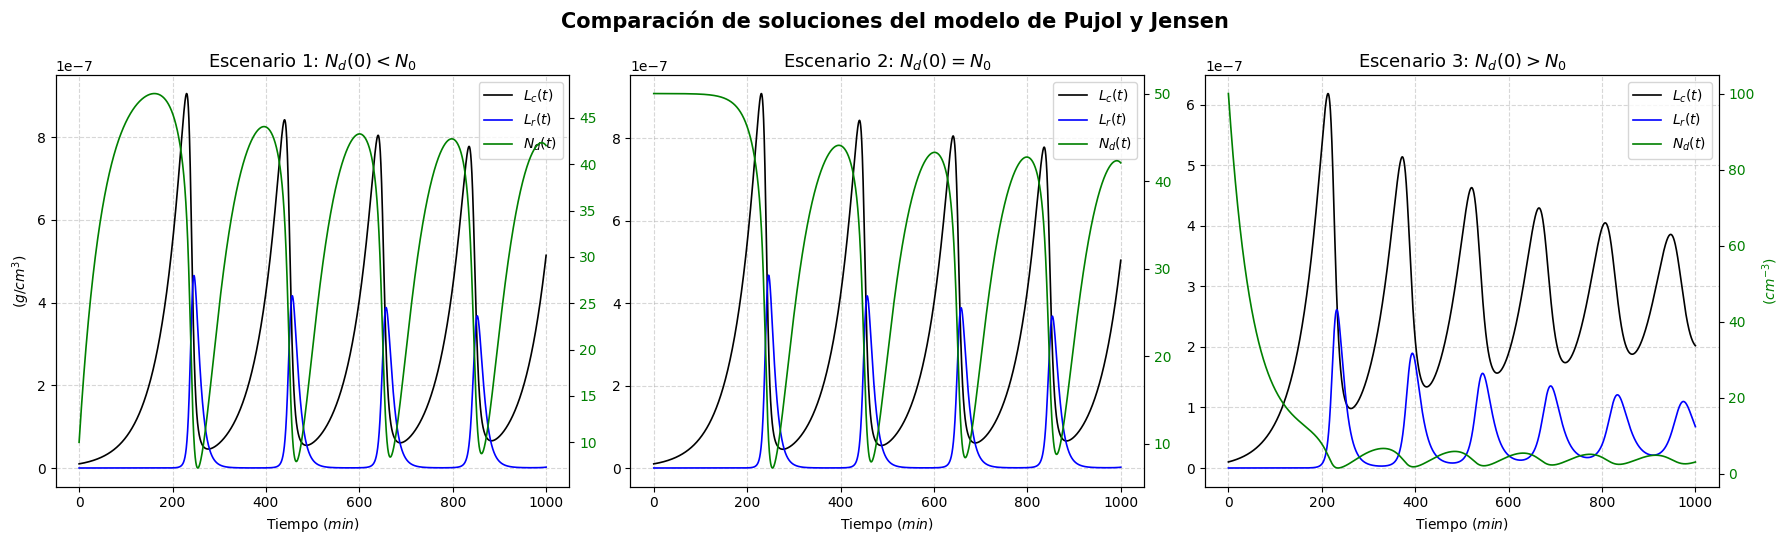

In [ ]:
# GRÁFICOS DE SOLUCIONES PARA LOS ESCENARIOS 1, 2 Y 3
# Generamos gráfico de una fila y tres columnas
fig, ax = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True)

fig.suptitle('Comparación de soluciones del modelo de Pujol y Jensen', fontsize=15, y=0.98, fontweight='bold')

# ESCENARIO 1 (Nd0 = 10)
# Eje izquierdo para Lc y Lr (g/cm^3)
l1_1 = ax[0].plot(t, lc_1, lw=1.2, color='black', label='$L_c(t)$')
l1_2 = ax[0].plot(t, lr_1, lw=1.2, color='blue', label='$L_r(t)$')
ax[0].set_title('Escenario 1: $N_d(0) < N_0$', fontsize=13)
ax[0].set_xlabel('Tiempo ($min$)')
ax[0].set_ylabel('($g/cm^3$)')
ax[0].tick_params(axis='y')
ax[0].grid(True, linestyle='--', alpha=0.5)
# Eje derecho espejo para Nd (cm^-3)
ax0_twin = ax[0].twinx()
l1_3 = ax0_twin.plot(t, nd_1, lw=1.2, color='green', label='$N_d(t)$')
ax0_twin.tick_params(axis='y', labelcolor='green')
# Unificar leyendas
lines_1 = l1_1 + l1_2 + l1_3
labels_1 = [l.get_label() for l in lines_1]
ax[0].legend(lines_1, labels_1, fontsize=10, loc='upper right')

# ESCENARIO 2 (Nd0 = 50)
# Eje izquierdo para Lc y Lr (g/cm^3)
l2_1 = ax[1].plot(t, lc_2, lw=1.2, color='black', label='$L_c(t)$')
l2_2 = ax[1].plot(t, lr_2, lw=1.2, color='blue', label='$L_r(t)$')
ax[1].set_title('Escenario 2: $N_d(0) = N_0$', fontsize=13)
ax[1].set_xlabel('Tiempo ($min$)')
ax[1].grid(True, linestyle='--', alpha=0.5)
# Eje derecho espejo para Nd (cm^-3)
ax1_twin = ax[1].twinx()
l2_3 = ax1_twin.plot(t, nd_2, lw=1.2, color='green', label='$N_d(t)$')
ax1_twin.tick_params(axis='y', labelcolor='green')
# Unificar leyendas
lines_2 = l2_1 + l2_2 + l2_3
labels_2 = [l.get_label() for l in lines_2]
ax[1].legend(lines_2, labels_2, fontsize=10, loc='upper right')


# ESCENARIO 3 (Nd0 = 100)
# Eje izquierdo para Lc y Lr (g/cm^3)
l3_1 = ax[2].plot(t, lc_3, lw=1.2, color='black', label='$L_c(t)$')
l3_2 = ax[2].plot(t, lr_3, lw=1.2, color='blue', label='$L_r(t)$')
ax[2].set_title('Escenario 3: $N_d(0) > N_0$', fontsize=13)
ax[2].set_xlabel('Tiempo ($min$)')
ax[2].grid(True, linestyle='--', alpha=0.5)
# Eje derecho espejo para Nd (cm^-3)
ax2_twin = ax[2].twinx()
l3_3 = ax2_twin.plot(t, nd_3, lw=1.2, color='green', label='$N_d(t)$')
ax2_twin.set_ylabel('($cm^{-3}$)', color='green')
ax2_twin.tick_params(axis='y', labelcolor='green')
# Unificar leyendas
lines_3 = l3_1 + l3_2 + l3_3
labels_3 = [l.get_label() for l in lines_3]
ax[2].legend(lines_3, labels_3, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

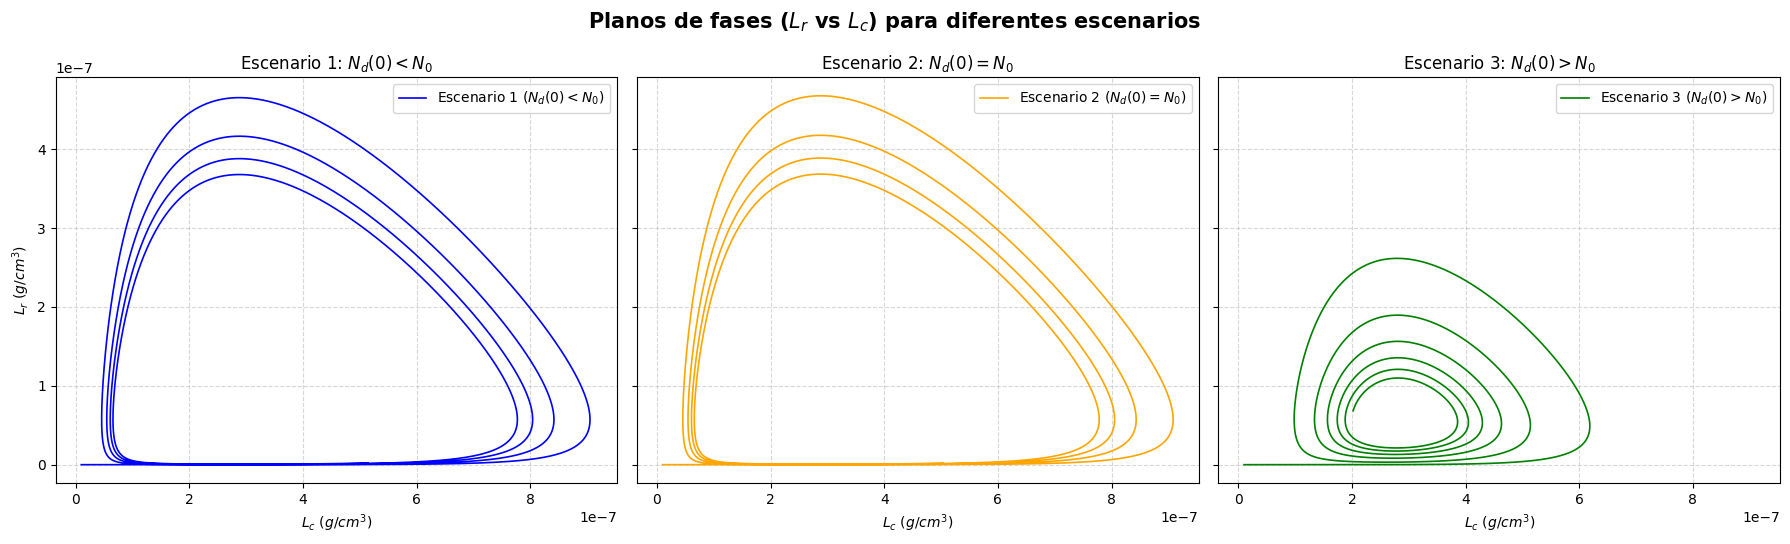

In [ ]:
# PLANO DE FASES PARA LOS ESCENARIOS 1, 2 Y 3

# Creamos una grilla de 1 fila y 3 columnas en paralelo
fig, ax = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True, sharey=True)

fig.suptitle('Planos de fases ($L_r$ vs $L_c$) para diferentes escenarios', fontsize=15, y=0.98, fontweight='bold')

# ESCENARIO 1 (Nd0 = 10)
ax[0].plot(lc_1, lr_1, lw=1.2, color='blue', label='Escenario 1 ($N_d(0) < N_0$)')
ax[0].set_title('Escenario 1: $N_d(0) < N_0$', fontsize=12)
ax[0].set_xlabel('$L_c$ $(g/cm^3)$')
ax[0].set_ylabel('$L_r$ $(g/cm^3)$')
ax[0].grid(True, linestyle='--', alpha=0.5)
'''# Punto de inicio (t=0) y fin (t=t_max)
ax[0].scatter(lc_1[0], lr_1[0], color='yellow', s=40, zorder=5, label='Inicio')
ax[0].scatter(lc_1[-1], lr_1[-1], color='purple', s=50, zorder=5, label='Fin')
# Punto crítico (teórico)
ax[0].scatter(eq_1[0], eq_1[1], color='red', s=60, zorder=5, label='Punto Crítico (Teórico)')'''
ax[0].legend(fontsize=10, loc='upper right')

# ESCENARIO 2 (Nd0 = 50)
ax[1].plot(lc_2, lr_2, lw=1.2, color='orange', label='Escenario 2 ($N_d(0) = N_0$)')
ax[1].set_title('Escenario 2: $N_d(0) = N_0$', fontsize=12)
ax[1].set_xlabel('$L_c$ $(g/cm^3)$')
# Ocultamos el label del eje Y en las columnas del medio/final porque comparten el eje (sharey=True)
ax[1].grid(True, linestyle='--', alpha=0.5)
'''# Punto de inicio (t=0) y fin (t=t_max)
ax[1].scatter(lc_2[0], lr_2[0], color='yellow', s=40, zorder=5, label='Inicio')
ax[1].scatter(lc_2[-1], lr_2[-1], color='purple', s=50, zorder=5, label='Fin')
# Punto crítico (teórico)
ax[1].scatter(eq_2[0], eq_2[1], color='red', s=60, zorder=5, label='Punto Crítico (Teórico)')'''
ax[1].legend(fontsize=10, loc='upper right')

# ESCENARIO 3 (Nd0 = 100)
ax[2].plot(lc_3, lr_3, lw=1.2, color='green', label='Escenario 3 ($N_d(0) > N_0$)')
ax[2].set_title('Escenario 3: $N_d(0) > N_0$', fontsize=12)
ax[2].set_xlabel('$L_c$ $(g/cm^3)$')
ax[2].grid(True, linestyle='--', alpha=0.5)
'''# Punto de inicio (t=0) y fin (t=t_max)
ax[2].scatter(lc_3[0], lr_3[0], color='yellow', s=40, zorder=5, label='Inicio')
ax[2].scatter(lc_3[-1], lr_3[-1], color='purple', s=50, zorder=5, label='Fin')
# Punto crítico (teórico)
ax[2].scatter(eq_3[0], eq_3[1], color='red', s=60, zorder=5, label='Punto Crítico (Teórico)')'''
ax[2].legend(fontsize=10, loc='upper right')


plt.tight_layout()
plt.show()

**Análisis escenarios 1, 2 y 3**

A simple vista, los gráficos de solución correspondientes a los *escenarios 1 y 2* muestran un comportamiento oscilatorio para las tres variables del sistema: el número de gotas de nube ($N_{d}$), el contenido de agua de nube ($L_{c}$) y el contenido de agua de lluvia ($L_{r}$). En ambos casos se observa una secuencia cíclica en la que inicialmente aumenta (Esc. 1) o mantiene estable (Esc. 2) el número de gotas de nube, favoreciendo el crecimiento del contenido de agua de nube por condensación. Una vez que $L_{c}$ alcanza valores elevados, comienzan a actuar los procesos de autoconversión y acreción, que promueven la formación de agua de lluvia ($L_{r}$). El aumento de la precipitación reduce progresivamente el contenido de agua de nube y el número de gotas, reiniciando el ciclo. La principal diferencia entre ambos escenarios radica en el estado inicial del sistema: en el escenario 1 sólo una fracción del potencial de aerosoles disponible ha sido activada inicialmente, lo que genera un período de transición inicial antes del establecimiento de las oscilaciones. En cambio, en el escenario 2 la totalidad de los aerosoles disponibles ya se encuentra activada desde el inicio.

Los planos de fase para los *escenarios 1 y 2* muestran trayectorias del tipo ciclo límite, es decir, que evolucionan hacia una órbita cerrada. Este comportamiento coincide con el reportado por Pujol y Jensen, quienes describen un régimen de oscilaciones periódicas sostenidas para estos escenarios. En las simulaciones que se realizaron se observa una disminución de la amplitud de las trayectorias entre ciclos, que se presume que podría estar asociada a limitaciones del método de integración empleado, en este caso el método de Euler. De todas maneras, el comportamiento general resulta consistente con el análisis de estabilidad de los puntos críticos, que para ambos casos se identificó un equilibrio no trivial inestable. En consecuencia, las soluciones no convergen hacia el estado estacionario representado por el punto crítico, sino que evolucionan hacia un régimen oscilatorio donde la formación de agua de nube y la producción de precipitación se alternan. Este comportamiento es característico de una bifurcación de Andronov–Hopf, en la que la pérdida de estabilidad del equilibrio da lugar a la aparición de un ciclo límite.

Por otra parte, el gráfico de solución para el *escenario 3* muestra un comportamiento oscilatorio para las tres variables al igual que los 1 y 2. La principal diferencia que se observa es que a medida que avanza el tiempo, ocurre una amortiguación con la consecuente disminución de la amplitud de forma progresiva hasta que alcanza el estado estacionario. Desde el punto de vista físico, el sistema parte de una condición en la que el número inicial de gotas de nube excede la concentración de aerosoles de fondo disponible ($N_{d}(0)> N_{0}$). En consecuencia, durante los primeros ciclos la conversión de agua de nube en lluvia y la precipitación reducen rápidamente la población de gotas, mientras que el ambiente no dispone de suficientes aerosoles para restituirla a su valor inicial. Como resultado, la intensidad de cada ciclo disminuye progresivamente hasta que las tasas de condensación, autoconversión, acreción e intercambio con el ambiente se equilibran, conduciendo al sistema hacia un régimen estacionario. El plano de fases confirma este comportamiento: las trayectorias describen una espiral que converge hacia el punto de equilibrio, evidenciando la presencia de una retroalimentación negativa que amortigua las perturbaciones iniciales.

### 4.3.2. Escenarios 4, 5 y 6

In [ ]:
# SOLUCIÓN NUMÉRICA DEL SISTEMA DE EDOS PARA LOS ESCENARIOS 4, 5, 6

# ESCENARIO 4
# Condiciones iniciales
ND0 =  10 # cm-3
LC0 = 10e-9 # cm-3
LR0 = 0 # g cm-3
N0 = 50 # cm-3
# Integración numérica por método de Euler (t_max = 1000 min)
t, lc_4, lr_4, nd_4 = euler_solver_3d(dLcdt, dLrdt, dNddt, 0, 1000, LC0, LR0, ND0, H)

# ESCENARIO 5
# Condiciones iniciales y parámetro N0
ND0 = 10 # cm-3
LC0 = 10e-7 # g cm-3
LR0 = 0 # g cm-3
N0 = 50 # cm-3
# Integración numérica por método de Euler (t_max = 1000 min)
t, lc_5, lr_5, nd_5 = euler_solver_3d(dLcdt, dLrdt, dNddt, 0, 1000, LC0, LR0, ND0, H)

# ESCENARIO 6
# Condiciones iniciales y parámetro N0
ND0 = 10 # cm-3
LC0 = 10e-6 # g cm-3
LR0 = 0 # g cm-3
N0 = 50 # cm-3
# Integración numérica por método de Euler (t_max = 1000 min)
t, lc_6, lr_6, nd_6 = euler_solver_3d(dLcdt, dLrdt, dNddt, 0, 1000, LC0, LR0, ND0, H)

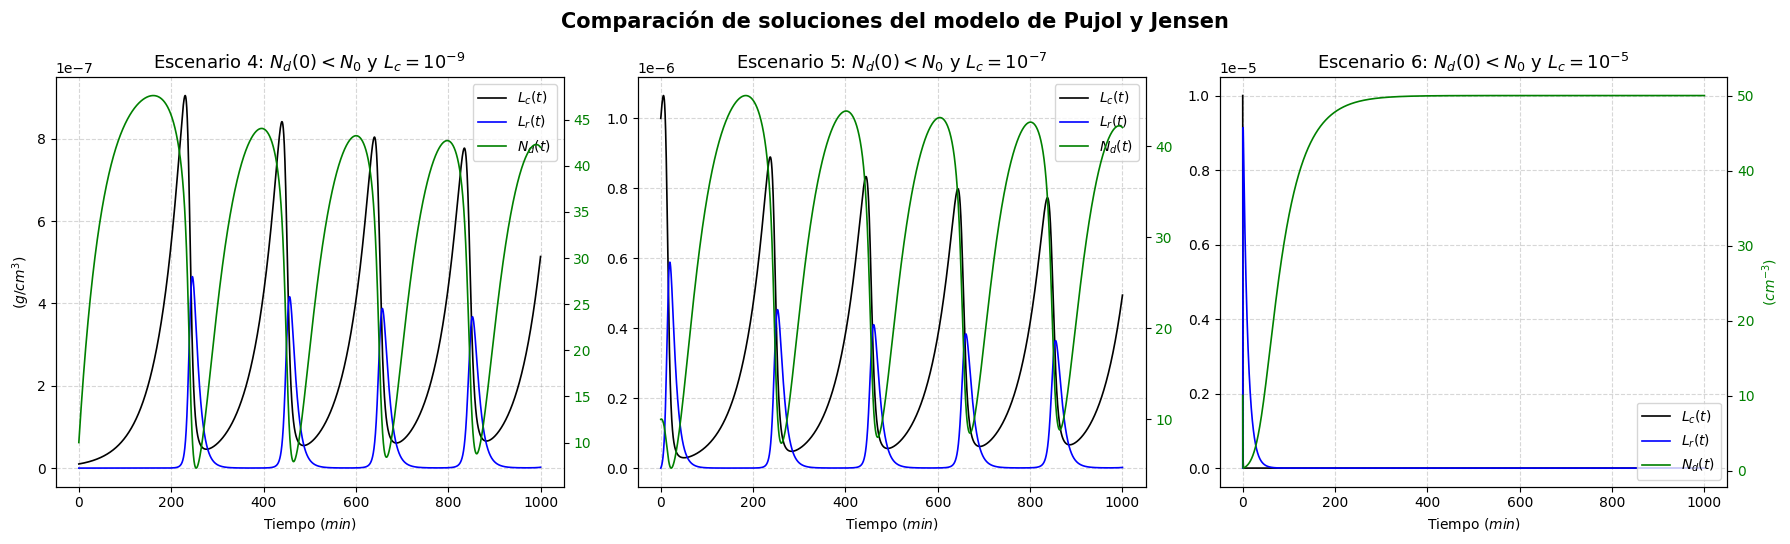

In [ ]:
# GRÁFICOS DE SOLUCIONES PARA LOS ESCENARIOS 4, 5 Y 6

# Generamos gráfico de una fila y tres columnas
fig, ax = plt.subplots(1, 3, figsize=(18, 5.5))#, sharex=True)

fig.suptitle('Comparación de soluciones del modelo de Pujol y Jensen', fontsize=15, y=0.98, fontweight='bold')

# ESCENARIO 4
# Eje izquierdo para Lc y Lr (g/cm^3)
l1_1 = ax[0].plot(t, lc_4, lw=1.2, color='black', label='$L_c(t)$')
l1_2 = ax[0].plot(t, lr_4, lw=1.2, color='blue', label='$L_r(t)$')
ax[0].set_title('Escenario 4: $N_d(0) < N_0$ y $L_{c} = 10^{-9}$', fontsize=13)
ax[0].set_xlabel('Tiempo ($min$)')
ax[0].set_ylabel('($g/cm^3$)')
ax[0].tick_params(axis='y')
ax[0].grid(True, linestyle='--', alpha=0.5)
# Eje derecho espejo para Nd (cm^-3)
ax0_twin = ax[0].twinx()
l1_3 = ax0_twin.plot(t, nd_4, lw=1.2, color='green', label='$N_d(t)$')
ax0_twin.tick_params(axis='y', labelcolor='green')
# Unificar leyendas
lines_1 = l1_1 + l1_2 + l1_3
labels_1 = [l.get_label() for l in lines_1]
ax[0].legend(lines_1, labels_1, fontsize=10, loc='upper right')

# ESCENARIO 5
# Eje izquierdo para Lc y Lr (g/cm^3)
l2_1 = ax[1].plot(t, lc_5, lw=1.2, color='black', label='$L_c(t)$')
l2_2 = ax[1].plot(t, lr_5, lw=1.2, color='blue', label='$L_r(t)$')
ax[1].set_title('Escenario 5: $N_d(0) < N_0$ y $L_{c} = 10^{-7}$', fontsize=13)
ax[1].set_xlabel('Tiempo ($min$)')
ax[1].grid(True, linestyle='--', alpha=0.5)
# Eje derecho espejo para Nd (cm^-3)
ax1_twin = ax[1].twinx()
l2_3 = ax1_twin.plot(t, nd_5, lw=1.2, color='green', label='$N_d(t)$')
ax1_twin.tick_params(axis='y', labelcolor='green')
# Unificar leyendas
lines_2 = l2_1 + l2_2 + l2_3
labels_2 = [l.get_label() for l in lines_2]
ax[1].legend(lines_2, labels_2, fontsize=10, loc='upper right')

# ESCENARIO 6
# Eje izquierdo para Lc y Lr (g/cm^3)
l3_1 = ax[2].plot(t, lc_6, lw=1.2, color='black', label='$L_c(t)$')
l3_2 = ax[2].plot(t, lr_6, lw=1.2, color='blue', label='$L_r(t)$')
ax[2].set_title('Escenario 6: $N_d(0) < N_0$ y $L_{c} = 10^{-5}$', fontsize=13)
ax[2].set_xlabel('Tiempo ($min$)')
ax[2].grid(True, linestyle='--', alpha=0.5)
# Eje derecho espejo para Nd (cm^-3)
ax2_twin = ax[2].twinx()
l3_3 = ax2_twin.plot(t, nd_6, lw=1.2, color='green', label='$N_d(t)$')
ax2_twin.set_ylabel('($cm^{-3}$)', color='green')
ax2_twin.tick_params(axis='y', labelcolor='green')
# Unificar leyendas
lines_3 = l3_1 + l3_2 + l3_3
labels_3 = [l.get_label() for l in lines_3]
ax[2].legend(lines_3, labels_3, fontsize=10, loc='lower right')

plt.tight_layout()
plt.show()

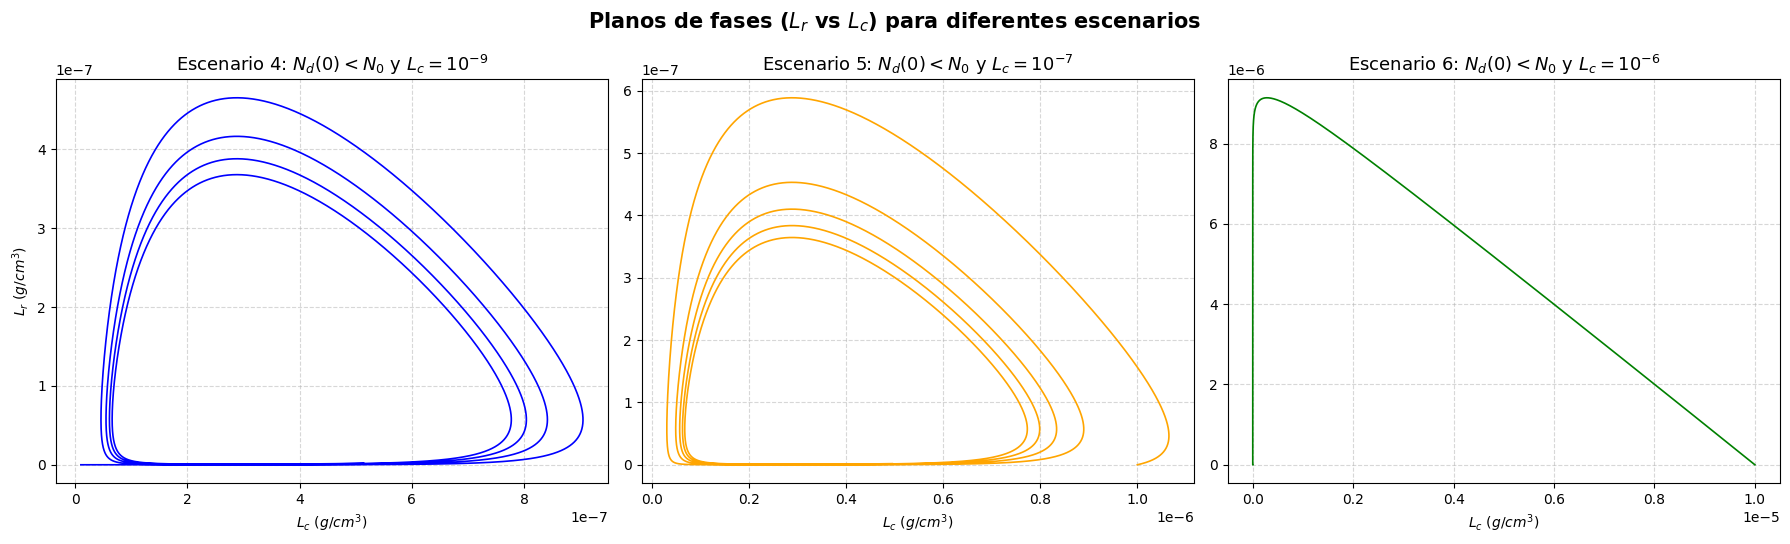

In [ ]:
# PLANO DE FASES PARA LOS ESCENARIOS 4, 5 Y 6

# Creamos una grilla de 1 fila y 3 columnas en paralelo
fig, ax = plt.subplots(1, 3, figsize=(18, 5.5))#, sharex=True, sharey=True)

fig.suptitle('Planos de fases ($L_r$ vs $L_c$) para diferentes escenarios', fontsize=15, y=0.98, fontweight='bold')

# ESCENARIO 4
ax[0].plot(lc_4, lr_4, lw=1.2, color='blue', label='Escenario 1 ($N_d(0) < N_0$)')
ax[0].set_title('Escenario 4: $N_d(0) < N_0$ y $L_{c} = 10^{-9}$', fontsize=13)
ax[0].set_xlabel('$L_c$ $(g/cm^3)$')
ax[0].set_ylabel('$L_r$ $(g/cm^3)$')
ax[0].grid(True, linestyle='--', alpha=0.5)
'''# Punto de inicio (t=0) y fin (t=t_max)
ax[0].scatter(lc_1[0], lr_1[0], color='black', s=40, zorder=5, label='Inicio')
ax[0].scatter(lc_1[-1], lr_1[-1], color='black', s=50, zorder=5, label='Fin')
# Punto crítico (teórico)
ax[0].scatter(eq_4[0], eq_4[1], color='red', s=60, zorder=5, label='Punto Crítico (Teórico)')'''

# ESCENARIO 5
ax[1].plot(lc_5, lr_5, lw=1.2, color='orange', label='Escenario 2 ($N_d(0) = N_0$)')
ax[1].set_title('Escenario 5: $N_d(0) < N_0$ y $L_{c} = 10^{-7}$', fontsize=13)
ax[1].set_xlabel('$L_c$ $(g/cm^3)$')
# Ocultamos el label del eje Y en las columnas del medio/final porque comparten el eje (sharey=True)
ax[1].grid(True, linestyle='--', alpha=0.5)
'''# Punto de inicio (t=0) y fin (t=t_max)
ax[1].scatter(lc_2[0], lr_2[0], color='black', s=40, zorder=5, label='Inicio')
ax[1].scatter(lc_2[-1], lr_2[-1], color='black', s=50, zorder=5, label='Fin')
# Punto crítico (teórico)
ax[1].scatter(eq_5[0], eq_5[1], color='red', s=60, zorder=5, label='Punto Crítico (Teórico)')'''

# ESCENARIO 6
ax[2].plot(lc_6, lr_6, lw=1.2, color='green', label='Escenario 3 ($N_d(0) > N_0$)')
ax[2].set_title('Escenario 6: $N_d(0) < N_0$ y $L_{c} = 10^{-6}$', fontsize=13)
ax[2].set_xlabel('$L_c$ $(g/cm^3)$')
ax[2].grid(True, linestyle='--', alpha=0.5)
'''# Punto de inicio (t=0) y fin (t=t_max)
ax[2].scatter(lc_3[0], lr_3[0], color='black', s=40, zorder=5, label='Inicio')
ax[2].scatter(lc_3[-1], lr_3[-1], color='black', s=50, zorder=5, label='Fin')
# Punto crítico (teórico)
ax[2].scatter(eq_6[0], eq_6[1], color='red', s=60, zorder=5, label='Punto Crítico (Teórico)')'''


plt.tight_layout()
plt.show()

**Análisis escenarios 4, 5 y 6**

Los gráficos de solución correspondientes a los *escenarios 4 y 5* muestran un comportamiento oscilatorio para las tres variables del sistema, al igual que en el escenario 1. Cuando el contenido inicial de agua de nube es bajo (Esc. 4), la escasez de masa líquida limita la autoconversión y mantiene al sistema durante más tiempo en una fase inicial de crecimiento. Al incrementar el valor de ($L_{c0}$) (Esc. 5), la mayor disponibilidad de agua favorece las colisiones entre gotitas, permitiendo que el sistema supere más rápidamente el umbral de formación de lluvia y reduciendo significativamente el tiempo de respuesta transitorio.

El escenario 6, por otro lado, presenta un comportamiento diferente. El gráfico de solución muestra que, ante una alta concentración inicial de agua de nube, el contenido de agua líquida se consume rápidamente. La dependencia a la cuarta del término de autoconversión con ($L_{c}$) favorece una conversión muy intensa de agua de nube en agua de lluvia, con la consecuente acreción y precipitación. De esta forma, contenido de agua de nube y de lluvia se agota en un corto intervalo de tiempo, impidiendo que el sistema se recupere y mantenga ciclos de oscilación.

Los planos de fase de los escenarios 4 y 5 muestran trayectorias del tipo ciclo límite, al igual que en los escenarios 1 y 2. Se presume que existe un error asociado a los resultados debido al método de integración utilizado, sin afectar la interpretación general. Por otro lado, el escenario 6 presenta una dinámica diferente. Se observa que, partiendo de las condiciones iniciales propuestas, el sistema no converge hacia el punto de equilibrio ni desarrolla un ciclo límite, sino que evoluciona de forma que ocurre un rápido agotamiento del contenido de agua líquida.

Los resultados obtenidos son consistentes con la clasificación de los puntos críticos hallados para los diferentes escenarios, los cuales fueron identificados como inestables. Si bien las trayectorias parten de condiciones alejadas del equilibrio, las soluciones de los escenarios 4 y 5 no convergen hacia el estado estacionario representado por el punto crítico, sino que evolucionan hacia un régimen oscilatorio en el que la formación de agua de nube y la producción de precipitación se alternan de forma periódica. En el escenario 6, por el contrario, la elevada concentración inicial de agua de nube tiene como consecuencia una rápida conversión de agua de nube en lluvia. De esta forma, la trayectoria tampoco converge al punto de equilibrio, sino que evoluciona hacia un estado prácticamente desprovisto de agua líquida.

# 5. Referencias y links

* [1] Koren, I., & Feingold, G. (2011). Aerosol-cloud-precipitation system as a predator-prey problem. *Proceedings of the National Academy of Sciences*, 108(30), 12227-12232. https://doi.org/10.1073/pnas.1101777108
* [2] Pujol, O., & Jensen, S. S. (2019). Dynamics of a simple cloud–rain system. *Atmospheric Research*, 88(3-4), 342-352. https://doi.org/10.1016/j.atmosres.2007.12.001
* Strogatz, S. H. (2018). Nonlinear Dynamics and Chaos: With Applications to Physics, Biology, Chemistry, and Engineering. Westview Press / CRC Press.
* Tauro, C., & Maglione, C. G. (2026). *Programación y Métodos Numéricos* [Diapositivas de clase]. Maestría en Aplicaciones de Información Espacial (MAIE), Instituto de Altos Estudios Espaciales Mario Gulich (CONAE-UNC).
* Documentación *fsolve Scipy*: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.fsolve.html
